In [20]:
import sys, platform, hashlib, datetime, zoneinfo
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from math import log10, sqrt

# ===== SEL IDENTITAS - JANGAN DIHAPUS =====
NAMA = "Radit Firansah"
NIM = "244107020196"

N = int(NIM[-3:])
PARAM = {
'b' : (N % 61) + 20,
'a' : round(1.0 + (N % 9) / 10, 1),
'c' : (N % 20) + 30,
'gamma': round(0.4 + (N % 6) * 0.25, 2),
'bit' : (N % 6) + 2,
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))

print('NAMA :', NAMA)
print('NIM :', NIM, '| N =', N)
for k, v in PARAM.items():
  print('%-6s :' % k, v)
print('WAKTU :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

NAMA : Muhammad Daniel Assaqovi
NIM : 244107020061 | N = 061
b      : 33
a      : 1.7
c      : 46
gamma  : 1.4
bit    : 6
WAKTU : 2026-09-17 22:18:44 WIB
SISTEM : 3.12.13 Linux-6.18.42-1-cachyos-lts-x86_64-with-glibc2.44
TOKEN : 1a063d09f1130fb6


In [ ]:
# ===== AKSES DATASET DARI GOOGLE DRIVE =====
# Colab : tambahkan folder Drive yang dibagikan ke "My Drive"
#         (klik kanan folder > Add shortcut to Drive), lalu jalankan sel ini.
# Lokal : taruh folder dataset di ./PCVK (opsional).
from pathlib import Path

try:
    from google.colab import drive
    drive.mount('/content/drive')
    _MYDRIVE = Path('/content/drive/MyDrive')
except Exception:
    _MYDRIVE = Path('.')


def _cari_dataset():
    kandidat = [_MYDRIVE / 'PCVK' / 'Images', _MYDRIVE / 'PCVK']
    for p in kandidat:
        if (p / 'lena.jpg').exists():
            return p
    try:
        for p in _MYDRIVE.rglob('lena.jpg'):
            return p.parent
    except Exception:
        pass
    return kandidat[0]


CONTOH = _cari_dataset()   # citra contoh bersama (lena.jpg, galaxy.jpg, noises/, ...)
BASE = CONTOH / NIM        # citra pribadi (KTM1a-d.jpg, OBJ1.jpg, NIGHT1.jpg)
if not (BASE / 'KTM1a.jpg').exists():
    BASE = CONTOH          # fallback ke citra contoh bila folder NIM belum ada

print('CONTOH :', CONTOH)
print('BASE   :', BASE)
print('Isi CONTOH:', sorted(p.name for p in CONTOH.iterdir())[:15])

# Praktikum Minggu 3
Operasi dasar pengolahan citra menggunakan gambar pada folder `img`.

## 1. Inverse Citra
Rumus: `g(x,y) = 255 - f(x,y)`.

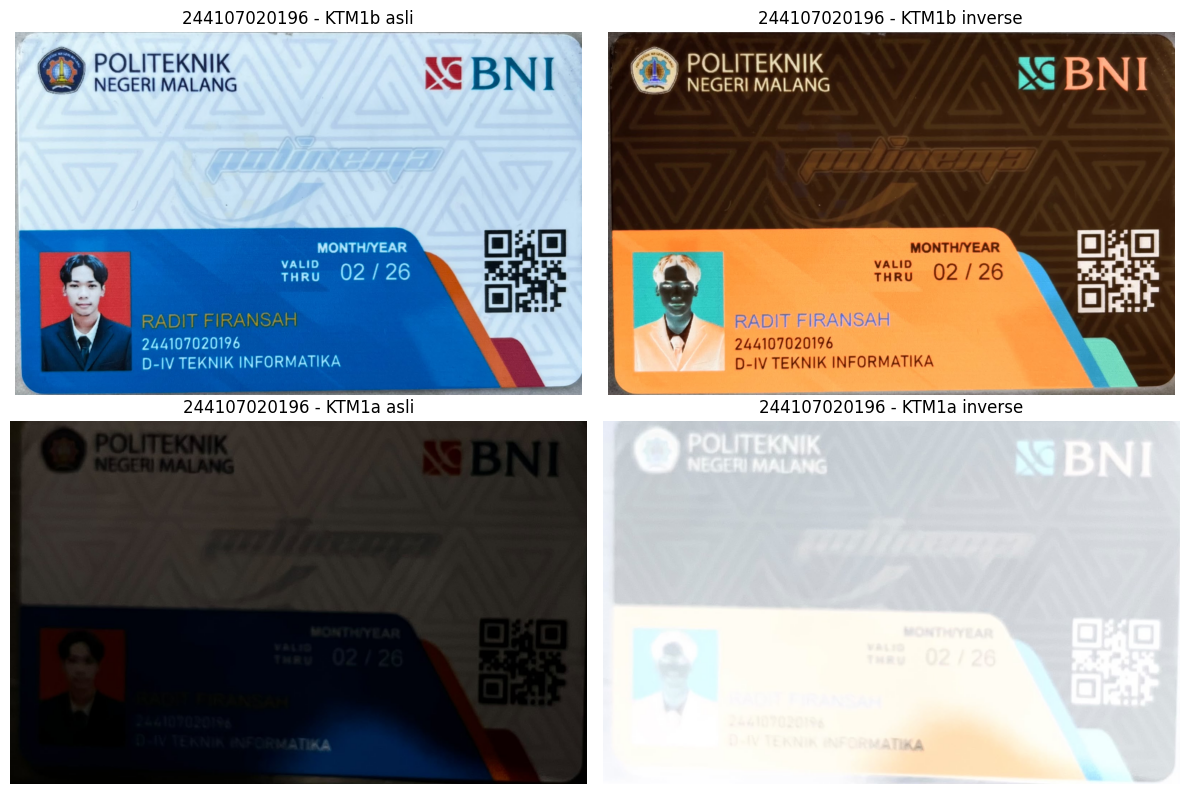

In [2]:
image_b = cv.imread(str(BASE / "KTM1b.jpg"))
image_a = cv.imread(str(BASE / "KTM1a.jpg"))
image_b = cv.cvtColor(image_b, cv.COLOR_BGR2RGB)
image_a = cv.cvtColor(image_a, cv.COLOR_BGR2RGB)

inverse_b = 255 - image_b
inverse_a = 255 - image_a

plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.imshow(image_b)
plt.title(NIM + " - KTM1b asli")
plt.axis("off")
plt.subplot(2, 2, 2)
plt.imshow(inverse_b)
plt.title(NIM + " - KTM1b inverse")
plt.axis("off")
plt.subplot(2, 2, 3)
plt.imshow(image_a)
plt.title(NIM + " - KTM1a asli")
plt.axis("off")
plt.subplot(2, 2, 4)
plt.imshow(inverse_a)
plt.title(NIM + " - KTM1a inverse")
plt.axis("off")
plt.tight_layout()
plt.show()

KTM1a diambil pada ruangan gelap sehingga sebagian besar pikselnya gelap. Saat diinversi, piksel gelap berubah menjadi terang dan rentang intensitasnya tetap sempit, sehingga hasilnya terlihat pucat dan berkabut. KTM1b memiliki pencahayaan lebih merata dan rentang intensitas lebih lebar, sehingga hasil inversenya tetap kontras.

## 2. Transformasi Kontras
Rumus yang dipakai: `g(x,y) = a × f(x,y)`, dengan `a = PARAM["a"]`.

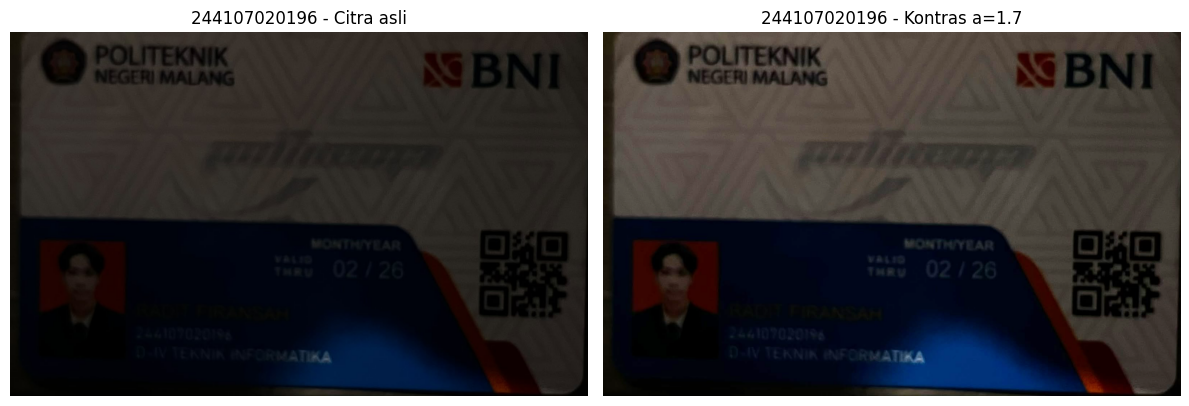

In [3]:
original = cv.imread(str(BASE / "KTM1a.jpg"))
original = cv.cvtColor(original, cv.COLOR_BGR2RGB)
contrast = np.clip(PARAM["a"] * original.astype(np.float32), 0, 255).astype(np.uint8)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(original)
plt.title(NIM + " - Citra asli")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(contrast)
plt.title(NIM + " - Kontras a=" + str(PARAM["a"]))
plt.axis("off")
plt.tight_layout()
plt.show()

## 3. Logarithmic Brightness dan Linear Brightness

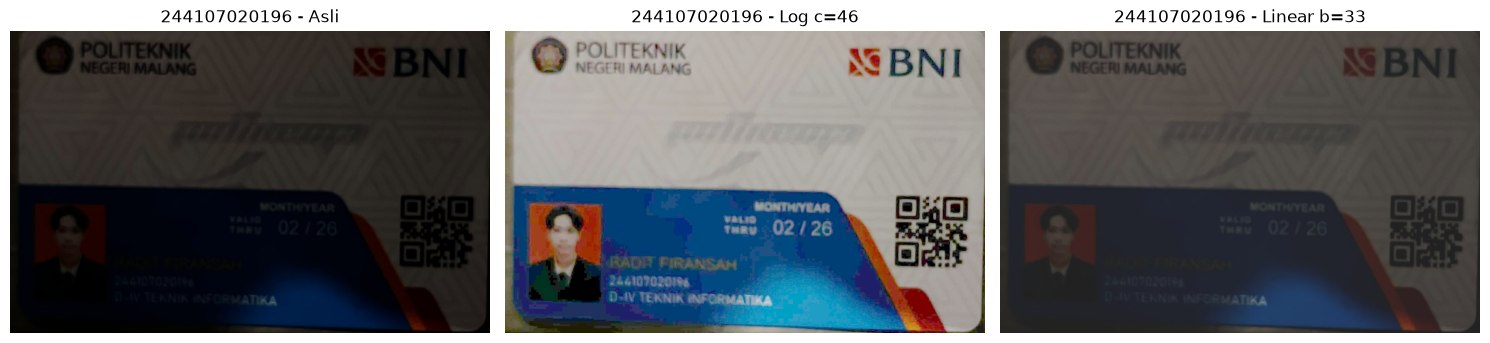

In [27]:
original = cv.imread(str(BASE / "KTM1a.jpg"))
original = cv.cvtColor(original, cv.COLOR_BGR2RGB).astype(np.float32)

logarithmic = np.clip(PARAM["c"] * np.log1p(original), 0, 255).astype(np.uint8)
linear = np.clip(original + PARAM["b"], 0, 255).astype(np.uint8)

plt.figure(figsize=(15, 8))
plt.subplot(2, 3, 1)
plt.imshow(original.astype(np.uint8))
plt.title(NIM + " - Asli")
plt.axis("off")
plt.subplot(2, 3, 2)
plt.imshow(logarithmic)
plt.title(NIM + " - Log c=" + str(PARAM["c"]))
plt.axis("off")
plt.subplot(2, 3, 3)
plt.imshow(linear)
plt.title(NIM + " - Linear b=" + str(PARAM["b"]))
plt.axis("off")
plt.tight_layout()
plt.show()

Logarithmic brightness lebih membantu membaca bagian gelap karena nilai intensitas rendah diperlebar. Linear brightness menambah nilai yang sama ke semua piksel. Bagian clipping terlihat putih pada gambar clipping dan dihitung sebagai piksel yang semua channel-nya bernilai 255.

## 4. Grayscale pada KTM1c

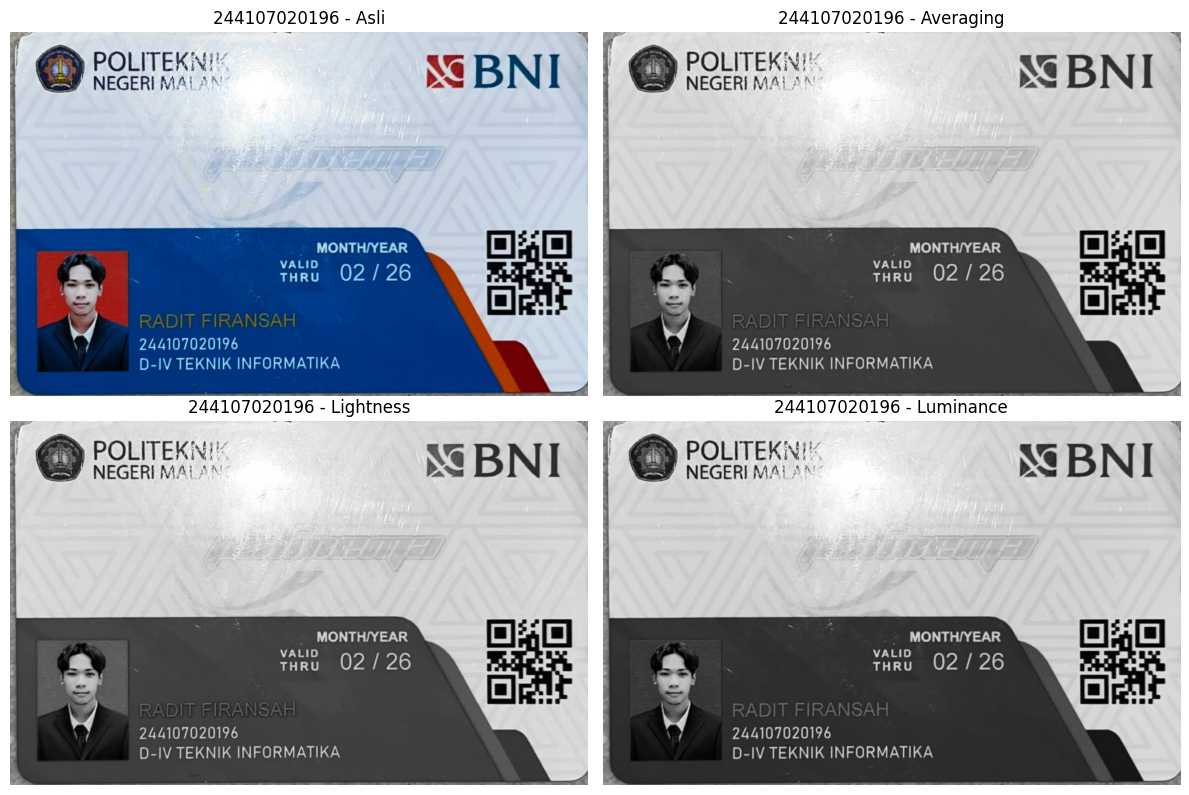

,Metode,Rata-rata,Simpangan baku
0,Averaging,149.948396,77.108273
1,Lightness,151.931472,75.427245
2,Luminance,144.430684,81.160027


In [5]:
original = cv.imread(str(BASE / "KTM1c.jpg"))
original = cv.cvtColor(original, cv.COLOR_BGR2RGB).astype(np.float32)
R = original[:, :, 0]
G = original[:, :, 1]
B = original[:, :, 2]

averaging = ((R + G + B) / 3).astype(np.uint8)
lightness = ((np.maximum.reduce([R, G, B]) + np.minimum.reduce([R, G, B])) / 2).astype(np.uint8)
luminance = (0.21 * R + 0.72 * G + 0.07 * B).astype(np.uint8)

tabel = pd.DataFrame({
    "Metode": ["Averaging", "Lightness", "Luminance"],
    "Rata-rata": [averaging.mean(), lightness.mean(), luminance.mean()],
    "Simpangan baku": [averaging.std(), lightness.std(), luminance.std()],
})

plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.imshow(original.astype(np.uint8))
plt.title(NIM + " - Asli")
plt.axis("off")
plt.subplot(2, 2, 2)
plt.imshow(averaging, cmap="gray")
plt.title(NIM + " - Averaging")
plt.axis("off")
plt.subplot(2, 2, 3)
plt.imshow(lightness, cmap="gray")
plt.title(NIM + " - Lightness")
plt.axis("off")
plt.subplot(2, 2, 4)
plt.imshow(luminance, cmap="gray")
plt.title(NIM + " - Luminance")
plt.axis("off")
plt.tight_layout()
plt.show()
tabel

Metode dengan simpangan baku terbesar memiliki penyebaran intensitas paling lebar. Metode tersebut dipilih sebagai metode yang paling jelas memisahkan teks dan latar kartu.

## 5. Menampilkan Satu Warna pada OBJ1
Objek pada gambar adalah mouse berwarna hitam. Tiga rentang HSV berikut dibandingkan.

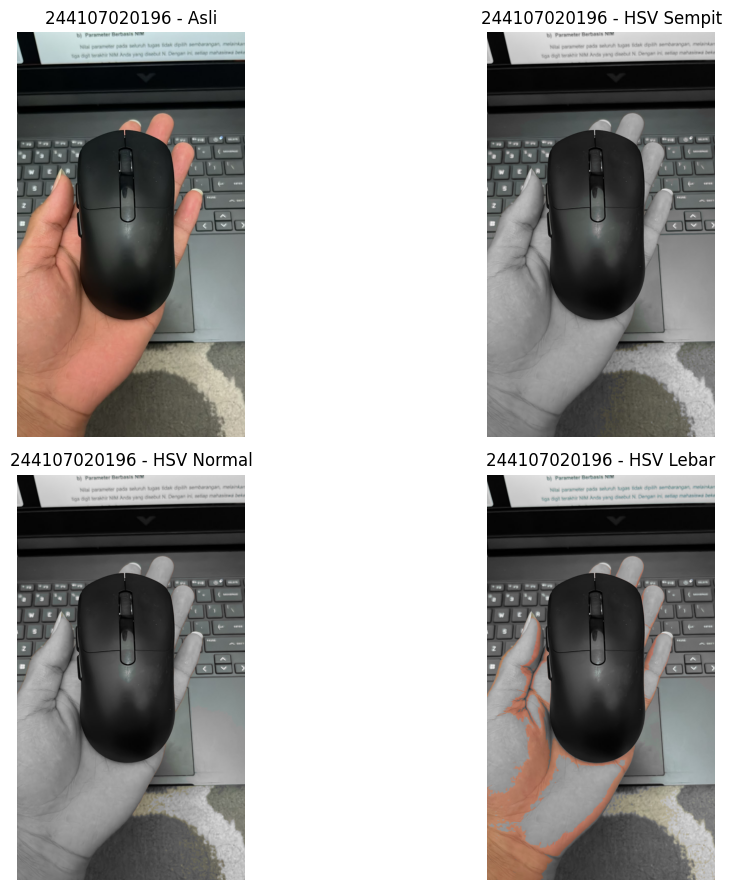

Sempit : ((0, 0, 70), (179, 55, 115))
Normal : ((0, 0, 100), (179, 90, 150))
Lebar : ((0, 0, 135), (179, 140, 190))


In [6]:
original = cv.imread(str(BASE / "OBJ1.jpg"))
original = cv.cvtColor(original, cv.COLOR_BGR2RGB)
hsv = cv.cvtColor(original, cv.COLOR_RGB2HSV)
gray = cv.cvtColor(original, cv.COLOR_RGB2GRAY)
gray = cv.cvtColor(gray, cv.COLOR_GRAY2RGB)

# H tidak dibatasi karena hitam tidak memiliki hue tertentu.
rentang_hsv = [
    ((0, 0, 70), (179, 55, 115)),
    ((0, 0, 100), (179, 90, 150)),
    ((0, 0, 135), (179, 140, 190)),
]
nama_rentang = ["Sempit", "Normal", "Lebar"]
hasil = []
for bawah, atas in rentang_hsv:
    mask = cv.inRange(hsv, np.array(bawah), np.array(atas))
    warna = gray.copy()
    warna[mask > 0] = original[mask > 0]
    hasil.append(warna)

plt.figure(figsize=(12, 9))
plt.subplot(2, 2, 1)
plt.imshow(original)
plt.title(NIM + " - Asli")
plt.axis("off")
for i in range(3):
    plt.subplot(2, 2, i + 2)
    plt.imshow(hasil[i])
    plt.title(NIM + " - HSV " + nama_rentang[i])
    plt.axis("off")
plt.tight_layout()
plt.show()
for nama, rentang in zip(nama_rentang, rentang_hsv):
    print(nama, ":", rentang)

Rentang sempit hanya mempertahankan bagian hitam yang paling gelap. Ketika rentang diperlebar, lebih banyak bagian abu-abu mouse ikut dipertahankan sebagai warna asli.

## 6. Gamma Correction pada KTM1a

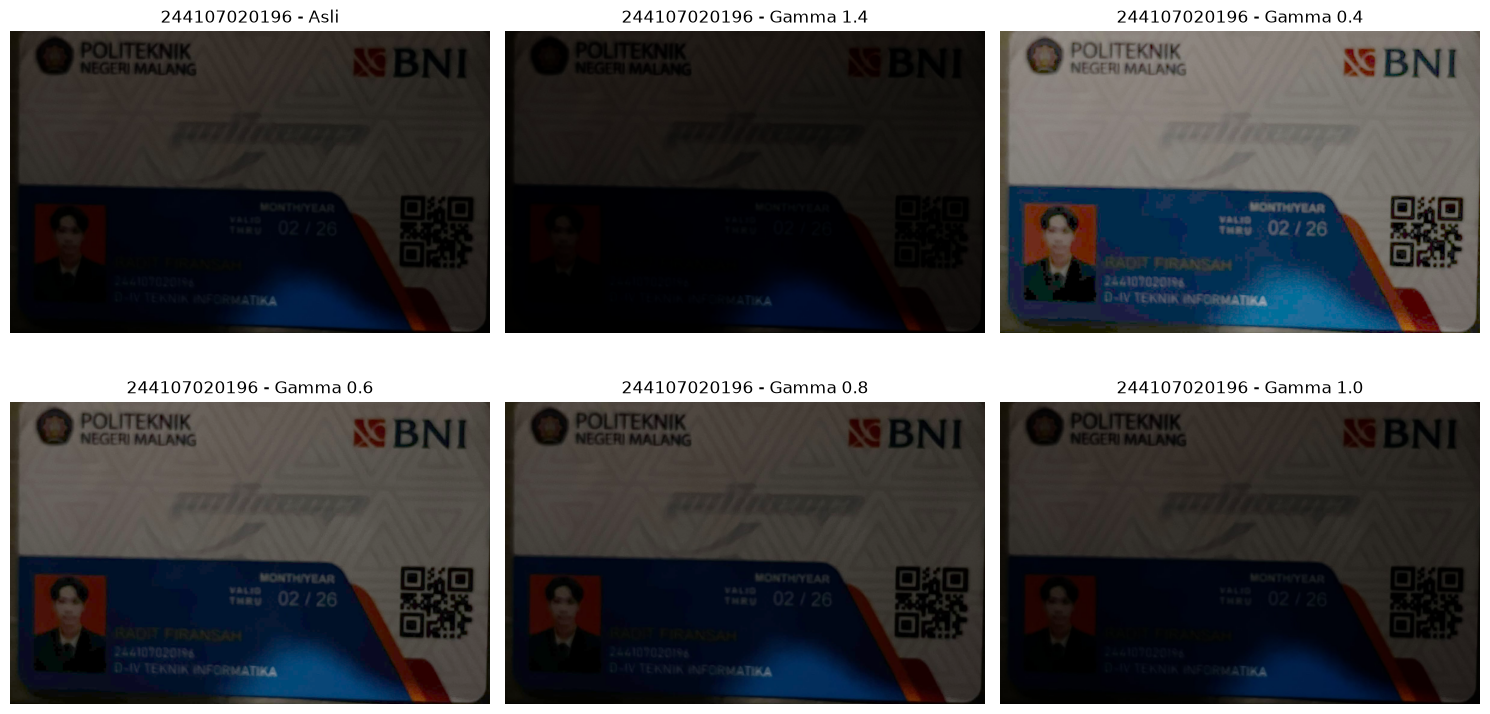

In [23]:
original = cv.imread(str(BASE / "KTM1a.jpg"))
original = cv.cvtColor(original, cv.COLOR_BGR2RGB).astype(np.float32) / 255

gamma_values = [PARAM["gamma"], 0.4, 0.6, 0.8, 1.0]
plt.figure(figsize=(15, 8))
plt.subplot(2, 3, 1)
plt.imshow((original * 255).astype(np.uint8))
plt.title(NIM + " - Asli")
plt.axis("off")
for i, gamma in enumerate(gamma_values, 2):
    hasil = np.clip(255 * original ** gamma, 0, 255).astype(np.uint8)
    plt.subplot(2, 3, i)
    plt.imshow(hasil)
    plt.title(NIM + " - Gamma " + str(gamma))
    plt.axis("off")
plt.tight_layout()
plt.show()

## 7. Simulasi Image Depth

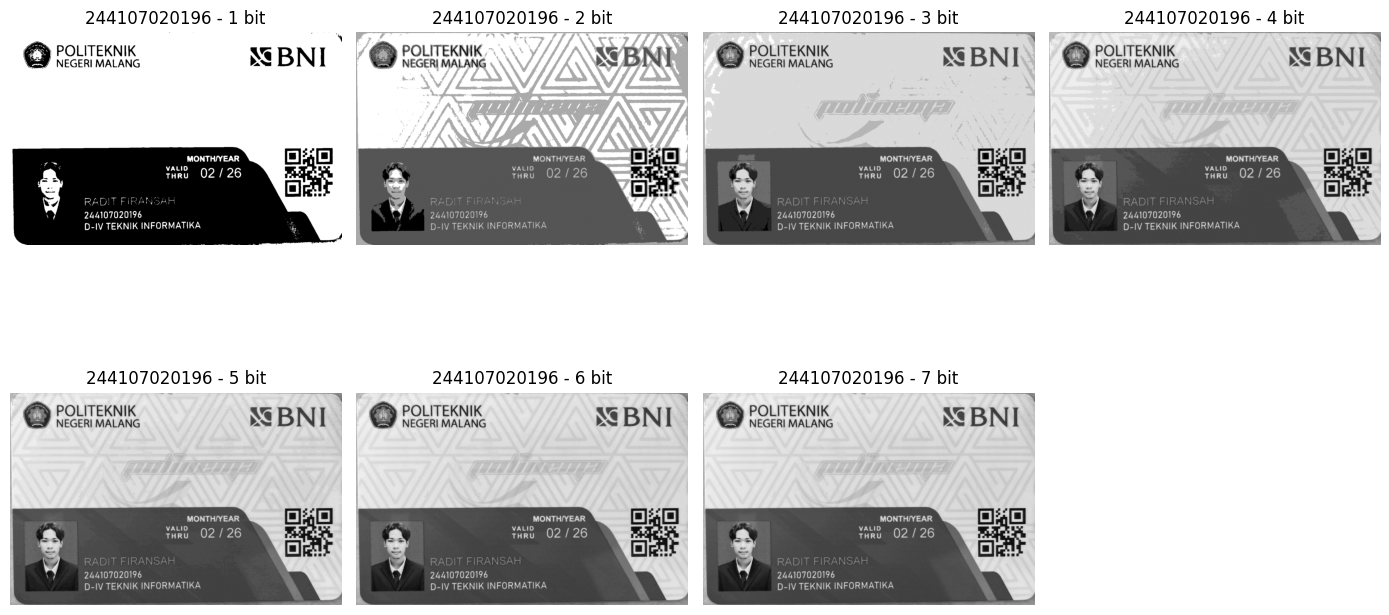

Parameter bit dari NIM: 6
Nama dan NIM masih terbaca dengan baik mulai sekitar 4 bit.


In [8]:
original = cv.imread(str(BASE / "KTM1b.jpg"), cv.IMREAD_GRAYSCALE)
plt.figure(figsize=(14, 8))
for bit in range(1, 8):
    level = 255 / (2 ** bit - 1)
    hasil = np.round(original / level) * level
    hasil = np.clip(hasil, 0, 255).astype(np.uint8)
    plt.subplot(2, 4, bit)
    plt.imshow(hasil, cmap="gray")
    plt.title(NIM + " - " + str(bit) + " bit")
    plt.axis("off")
plt.tight_layout()
plt.show()
print("Parameter bit dari NIM:", PARAM["bit"])
print("Nama dan NIM masih terbaca dengan baik mulai sekitar 4 bit.")

## 8. Average Denoising

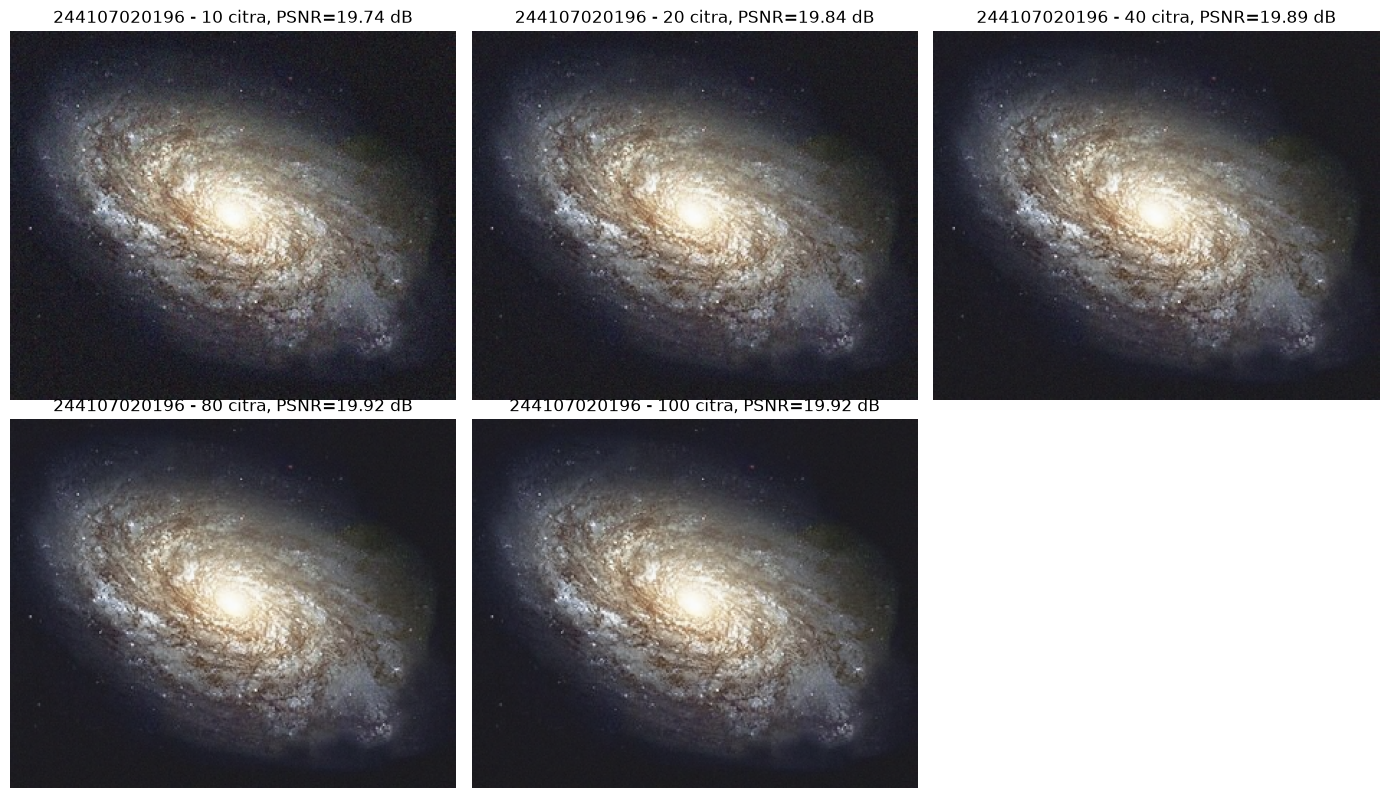

,Jumlah citra,PSNR (dB)
0,10,19.735622
1,20,19.840488
2,40,19.892767
3,80,19.915895
4,100,19.921961


In [33]:
import glob

original = cv.imread(str(CONTOH / "galaxy.jpg"))
if original is None:
    raise FileNotFoundError("galaxy.jpg tidak ditemukan")

noise_files = sorted([str(p) for p in sorted(CONTOH.glob("**/noises/*.jpg"))])
if len(noise_files) == 0:
    raise FileNotFoundError("Folder noises berisi citra noise belum ditemukan")

h, w = original.shape[:2]
noisy_images = []
for file in noise_files:
    image = cv.imread(file)
    if image is not None:
        noisy_images.append(cv.resize(image, (w, h)))

if len(noisy_images) < 100:
    raise ValueError("Minimal 100 citra noise diperlukan")

jumlah = [10, 20, 40, 80, 100]
hasil_semua = []
psnr_semua = []
for n in jumlah:
    hasil = np.mean(noisy_images[:n], axis=0).astype(np.uint8)
    mse = np.mean((original.astype(np.float32) - hasil.astype(np.float32)) ** 2)
    nilai_psnr = float("inf") if mse == 0 else 20 * log10(255 / sqrt(mse))
    hasil_semua.append(hasil)
    psnr_semua.append(nilai_psnr)

plt.figure(figsize=(14, 8))
for i in range(len(jumlah)):
    plt.subplot(2, 3, i + 1)
    plt.imshow(cv.cvtColor(hasil_semua[i], cv.COLOR_BGR2RGB))
    plt.title(NIM + " - " + str(jumlah[i]) + " citra, PSNR=" + f"{psnr_semua[i]:.2f} dB")
    plt.axis("off")
plt.tight_layout()
plt.show()
pd.DataFrame({"Jumlah citra": jumlah, "PSNR (dB)": psnr_semua})

Semakin banyak citra yang dirata-ratakan, noise acak semakin berkurang dan PSNR cenderung meningkat. Kenaikan PSNR biasanya mulai tidak terlalu besar ketika jumlah citra sudah banyak.

## 9. Image Masking untuk Menyamarkan Data Pribadi

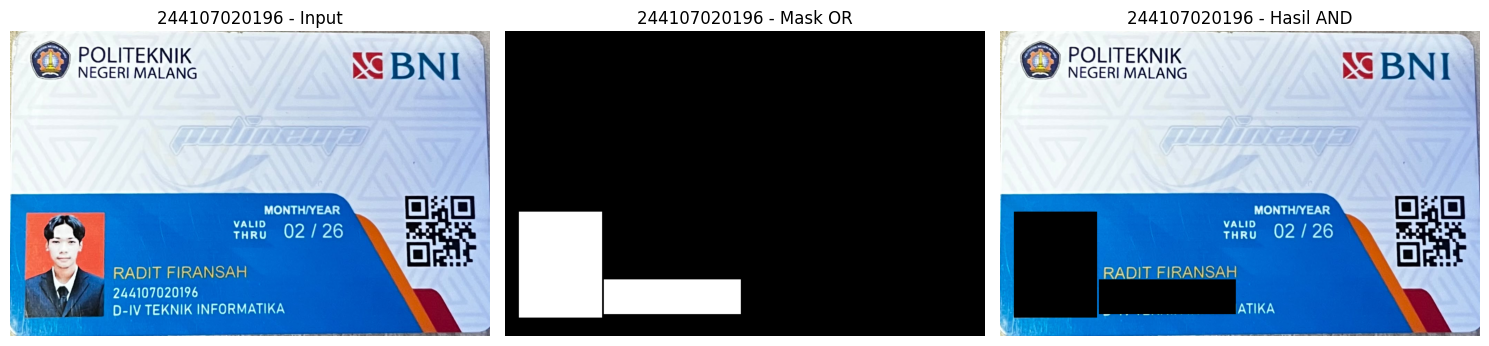

Koordinat wajah: y=520:825, x=40:280
Koordinat NIM  : y=715:815, x=285:680


In [10]:
original = cv.imread(str(BASE / "KTM1d.jpg"))
h, w = original.shape[:2]

# Koordinat ditulis sebagai [y1:y2, x1:x2].
mask_wajah = np.zeros((h, w), dtype=np.uint8)
mask_nim = np.zeros((h, w), dtype=np.uint8)
mask_wajah[520:825, 40:280] = 255
mask_nim[715:815, 285:680] = 255
mask = cv.bitwise_or(mask_wajah, mask_nim)

# AND dengan komplemen mask membuat area mask menjadi hitam.
hasil = cv.bitwise_and(original, original, mask=cv.bitwise_not(mask))

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(cv.cvtColor(original, cv.COLOR_BGR2RGB))
plt.title(NIM + " - Input")
plt.axis("off")
plt.subplot(1, 3, 2)
plt.imshow(mask, cmap="gray")
plt.title(NIM + " - Mask OR")
plt.axis("off")
plt.subplot(1, 3, 3)
plt.imshow(cv.cvtColor(hasil, cv.COLOR_BGR2RGB))
plt.title(NIM + " - Hasil AND")
plt.axis("off")
plt.tight_layout()
plt.show()
print("Koordinat wajah: y=520:825, x=40:280")
print("Koordinat NIM  : y=715:815, x=285:680")

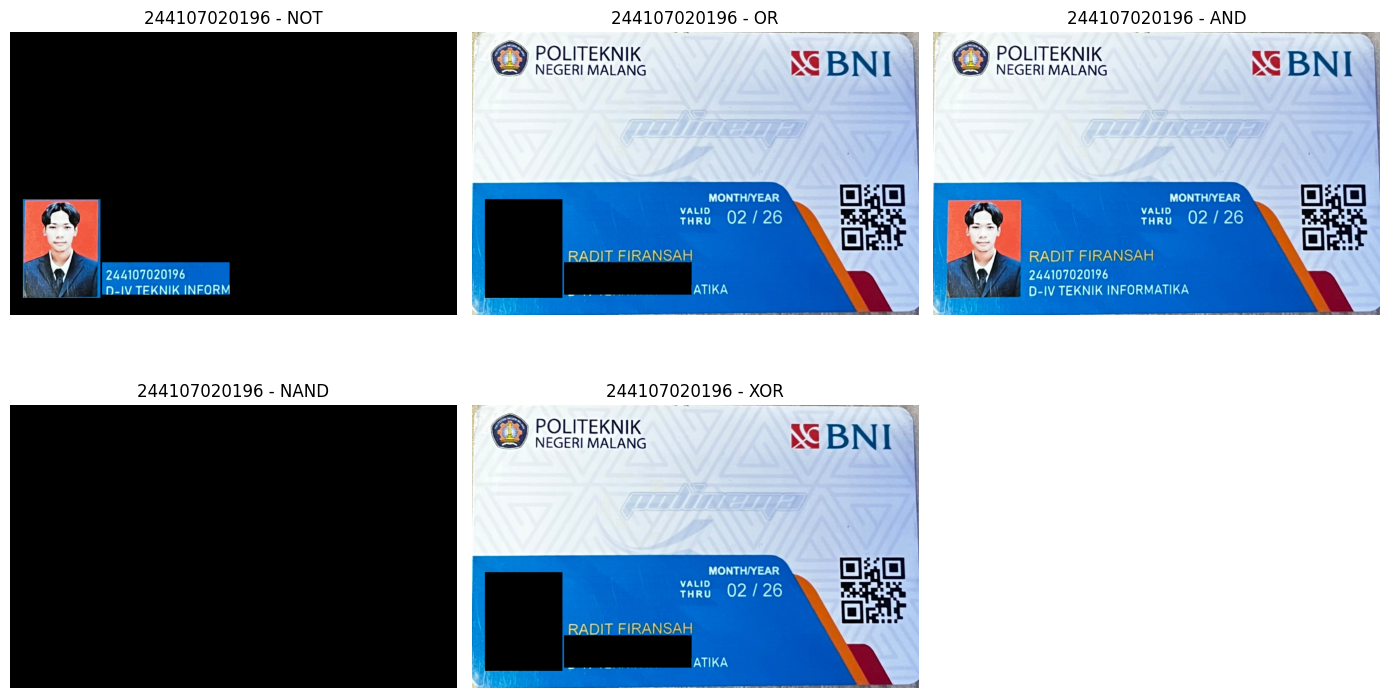

OR paling sesuai karena menggabungkan area wajah dan area NIM.


In [11]:
operator_masks = {
    "NOT": cv.bitwise_not(mask),
    "OR": cv.bitwise_or(mask_wajah, mask_nim),
    "AND": cv.bitwise_and(mask_wajah, mask_nim),
    "NAND": cv.bitwise_not(cv.bitwise_and(mask_wajah, mask_nim)),
    "XOR": cv.bitwise_xor(mask_wajah, mask_nim),
}

plt.figure(figsize=(14, 8))
for i, (nama, operator_mask) in enumerate(operator_masks.items(), 1):
    keluaran = original.copy()
    keluaran[operator_mask > 0] = 0
    plt.subplot(2, 3, i)
    plt.imshow(cv.cvtColor(keluaran, cv.COLOR_BGR2RGB))
    plt.title(NIM + " - " + nama)
    plt.axis("off")
plt.tight_layout()
plt.show()
print("OR paling sesuai karena menggabungkan area wajah dan area NIM.")

OR menutup area wajah atau NIM. AND hanya menutup irisan kedua mask sehingga tidak cocok untuk dua area yang terpisah. NOT dan NAND menghasilkan komplemen mask. XOR menutup area yang hanya berada pada salah satu mask.

## 10. Perbaikan Foto Malam Hari

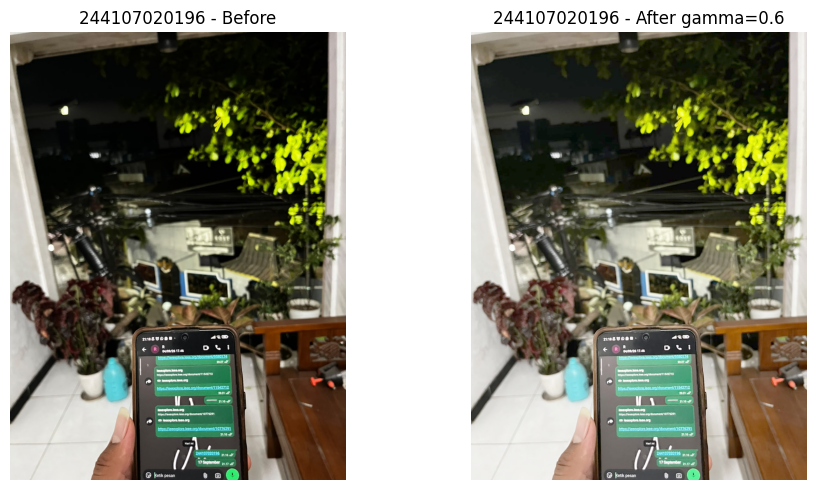

Metode: Gamma Correction
Alasan: menaikkan detail pada area foto yang gelap.
Parameter: gamma = 0.6
Risiko: bagian lampu atau daun yang sudah terang dapat mengalami clipping.


In [12]:
original = cv.imread(str(BASE / "NIGHT1.jpg"))
original = cv.cvtColor(original, cv.COLOR_BGR2RGB).astype(np.float32)
gamma = 0.6
hasil = np.clip(255 * (original / 255) ** gamma, 0, 255).astype(np.uint8)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(original.astype(np.uint8))
plt.title(NIM + " - Before")
plt.axis("off")
plt.subplot(1, 2, 2)
plt.imshow(hasil)
plt.title(NIM + " - After gamma=" + str(gamma))
plt.axis("off")
plt.tight_layout()
plt.show()
print("Metode: Gamma Correction")
print("Alasan: menaikkan detail pada area foto yang gelap.")
print("Parameter: gamma = 0.6")
print("Risiko: bagian lampu atau daun yang sudah terang dapat mengalami clipping.")

Gamma correction dengan gamma 0,6 dipilih karena foto malam memiliki banyak area gelap. Hasilnya lebih terang dan detail area gelap lebih terlihat. Risikonya adalah detail pada bagian yang sudah terang dapat hilang karena clipping.